# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `[Eri Masahisa]`  
**SFU ID:** `[301604643]`  
**Date:** `[2026/7/5]`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [10]:
df_ab = pd.read_csv('phigma_ab_study.csv')

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                 object
ab_group                                object
device_type                             object
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                             object
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NaN,5,1,1,0,38,17.91


In [11]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,1323,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,U10149,control,desktop,NaN,NaN,EU,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,593,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [12]:
# Missing values
df_ab.isnull().sum()


user_id                                  0
ab_group                                 0
device_type                              0
account_age_days                         0
prior_whiteboard_sessions                0
plan_region                            677
num_collaborators                        0
feature_tour_completed                   0
templates_used                           0
ai_suggestions_used                      0
whiteboard_actions_per_session           0
avg_whiteboard_session_duration_min      0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


In [ ]:
BEGIN
    Load target outcome variable

    // 1. Normality & Transformation Visualizations
    Initialize three-panel visual layout
    
    Draw histogram of raw outcome distribution
    Transform outcome variable using natural logarithm
    Draw histogram of log-transformed outcome distribution
    Draw Q-Q plot comparing log-transformed distribution to a normal distribution
    
    Render visualizations

    // 2. Statistical Diagnostics
    Compute and output skewness for both raw and log-transformed distributions
END

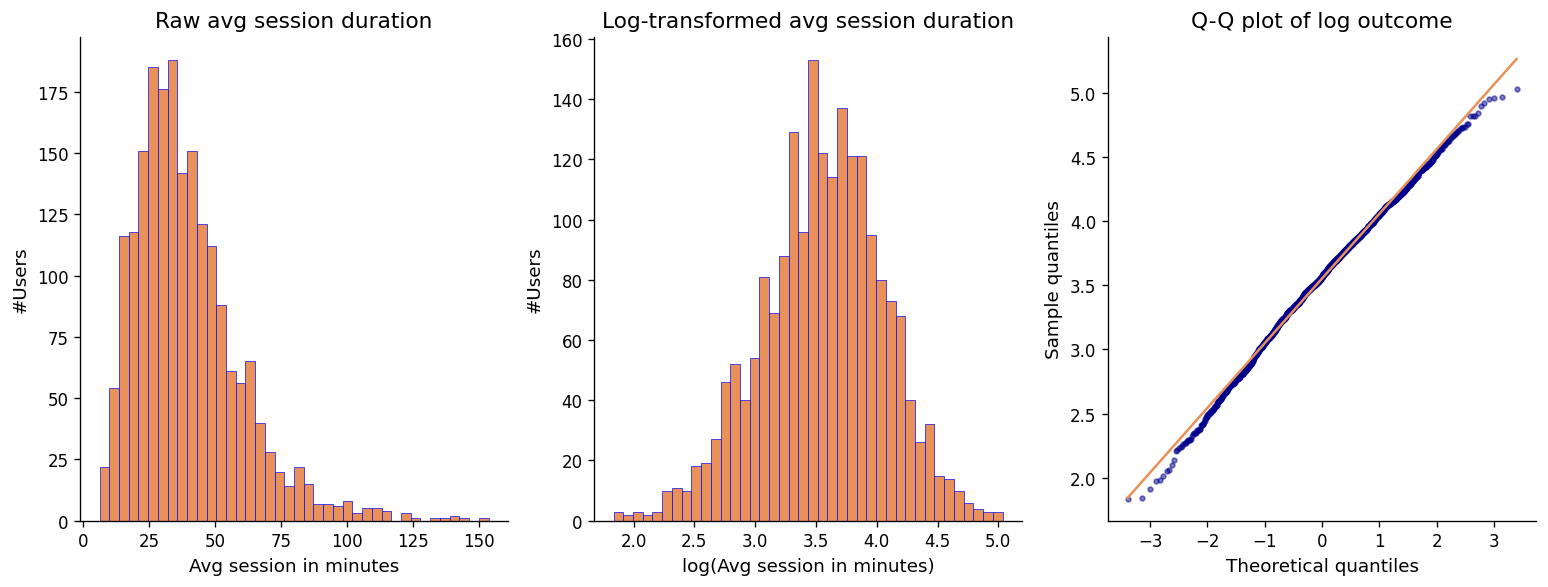

Skewness – raw outcome : 1.3758
Skewness – log outcome : -0.2133
(R² of Q-Q fit)        : 0.9969


In [13]:
y_raw = df_ab['avg_whiteboard_session_duration_min']
y_log = np.log(y_raw)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

# raw data frame
axes[0].hist(y_raw, bins=40, color=ACCENT, edgecolor='blue', linewidth=0.4)
axes[0].set_title("Raw avg session duration")
axes[0].set_xlabel("Avg session in minutes")
axes[0].set_ylabel("#Users")

# log transformed
axes[1].hist(y_log, bins=40, color=ACCENT, edgecolor='blue', linewidth=0.4)
axes[1].set_title("Log-transformed avg session duration")
axes[1].set_xlabel("log(Avg session in minutes)")
axes[1].set_ylabel("#Users")

# Q-Q plot of log outcome
(osm, osr), (slope, intercept, r) = stats.probplot(y_log, dist='norm')
axes[2].scatter(osm, osr, color='darkblue', s=8, alpha=0.5)
axes[2].plot([osm.min(), osm.max()],
             [slope * osm.min() + intercept, slope * osm.max() + intercept],
             color=ACCENT, linewidth=1.5)
axes[2].set_title("Q-Q plot of log outcome")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Sample quantiles")

plt.tight_layout()
plt.show()


skew_raw = stats.skew(y_raw)
skew_log = stats.skew(y_log)
r_squared = r ** 2  

print(f"Skewness – raw outcome : {skew_raw:.4f}")
print(f"Skewness – log outcome : {skew_log:.4f}")
print(f"(R² of Q-Q fit)        : {r_squared:.4f}")

**✏️ Your interpretation (A1.1):**

First, the raw outcome has a skewness of 1.38, which shows that it is right-skewed with a long tail. After the log transformation, the skewness became -0.21, so the distribution becomes more symmetric. The Q-Q plot has an R² value of 0.997, indicating that the points are very close to the diagonal line and the data is close to a normal distribution. Therefore, I would use the log-transformed outcome for the model.


#### A1.2 — Examine the confounders

In [ ]:
// Define the analytical pipeline
BEGIN
    Load AB testing dataset

    // 1. Visual Exploratory Data Analysis
    Initialize side-by-side visualization layouts
    
    Draw boxplot comparison of AI suggestion usage across experimental groups
    Draw scatter plot comparing whiteboard activity density against session durations
    
    Optimize layout and display visualizations

    // 2. Statistical Analysis
    Calculate and print the correlation between whiteboard activity and session duration
    Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
END

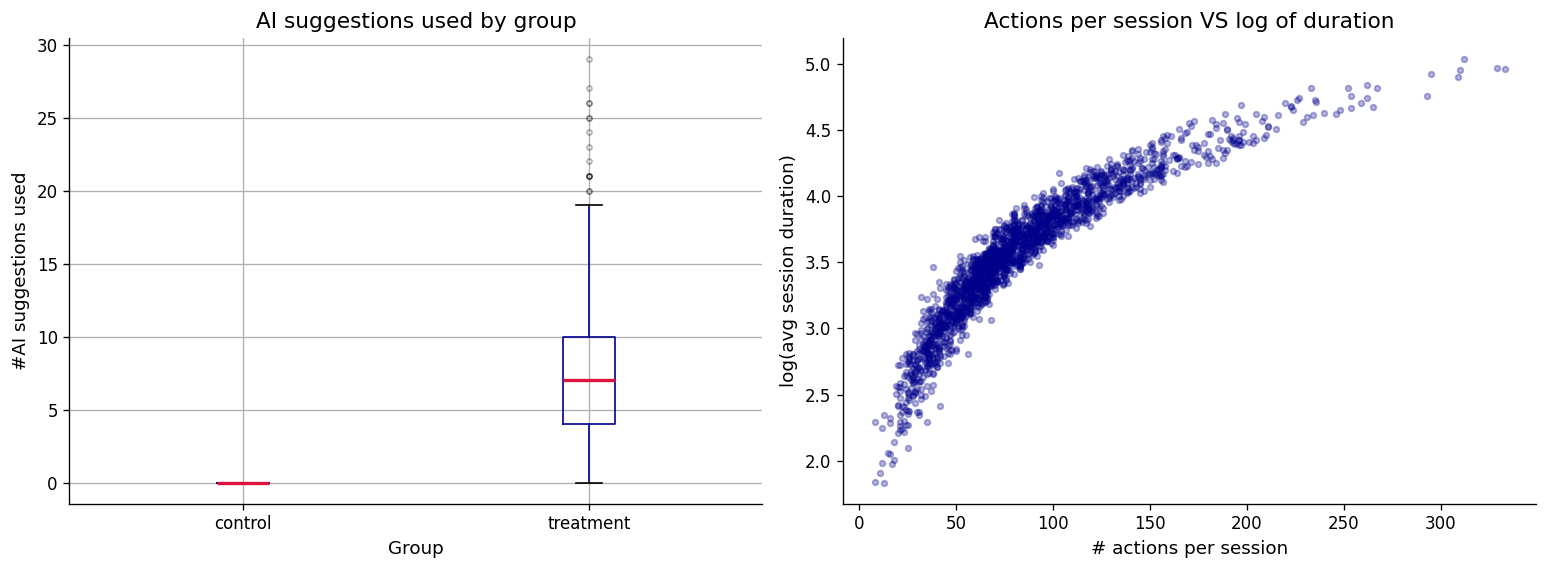

Pearson r (whiteboard_actions_per_session vs log_duration): 0.9136

Descriptive stats for ai_suggestions_used by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: boxplot of ai suggestions
df_ab.boxplot(column='ai_suggestions_used', by='ab_group', ax=axes[0],
              boxprops=dict(color='darkblue'),
              medianprops=dict(color='crimson', lw=2),
              whiskerprops=dict(color='darkblue'),
              capprops=dict(color='black'),
              flierprops=dict(marker='o', color='blue', alpha=0.3, markersize=3)
              )
axes[0].set_xlabel('Group')
axes[0].set_title("AI suggestions used by exp group")
axes[0].set_ylabel('#AI suggestions used')
plt.sca(axes[0])
plt.title("AI suggestions used by group")
plt.suptitle('')

# right: scatter plot of whiteboard actions per session vs log(duration)
log_dur = np.log(df_ab['avg_whiteboard_session_duration_min'])
axes[1].scatter(df_ab['whiteboard_actions_per_session'], log_dur,
                color='darkblue', alpha=0.3, s=12)
axes[1].set_title('Actions per session VS log of duration')
axes[1].set_xlabel('# actions per session')
axes[1].set_ylabel('log(avg session duration)')

plt.tight_layout()
plt.show()

corr_actions = df_ab['whiteboard_actions_per_session'].corr(log_dur)
print(f"Pearson r (whiteboard_actions_per_session vs log_duration): {corr_actions:.4f}")

print("\nDescriptive stats for ai_suggestions_used by group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe().round(2))

**✏️ Your interpretation (A1.2):**

The descriptive statistics show that the mean of ai_suggestions_used is 0 for the control group and 7.33 for the treatment group. This is expected because the control group did not have access to the AI assistant. This variable contains almost the same information as ab_group. If both variables are included in the model, it becomes difficult to distinguish the effect of having access to the AI assistant from the effect of using the AI more often.

The scatter plot shows a very strong positive correlation between whiteboard_actions_per_session and log(duration) (r = 0.91). This means that longer sessions usually have more whiteboard actions. However, whiteboard_actions_per_session is an outcome of user behavior, not a cause of session duration. Therefore, I would exclude both ai_suggestions_used and whiteboard_actions_per_session from the model.


#### A1.3 — Predictor distributions and relationships with outcome

In [ ]:
BEGIN
    Define list of numerical predictor variables
    Compute log-transformed outcome variable

    Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)

    FOR each predictor variable:
        // Top row: Univariate Analysis
        Draw histogram to show distribution of the predictor
        
        // Bottom row: Bivariate Analysis
        Draw scatter plot comparing predictor against log-transformed outcome
        Calculate correlation coefficient between predictor and log-transformed outcome
        Annotate plot with correlation coefficient
    END FOR

    Add global title and render layout
END

In [ ]:
BEGIN
    Define list of categorical predictor variables
    Initialize visual grid layout (1 row by N columns, where N is the number of categories)

    FOR each categorical variable:
        Retrieve unique category levels
        
        Group log-transformed outcome values by category levels
        
        Draw boxplots of log-transformed outcome grouped by category level
        Rotate category axis labels for readability
        
        Label axis and set titles
    END FOR

    Render layout
END

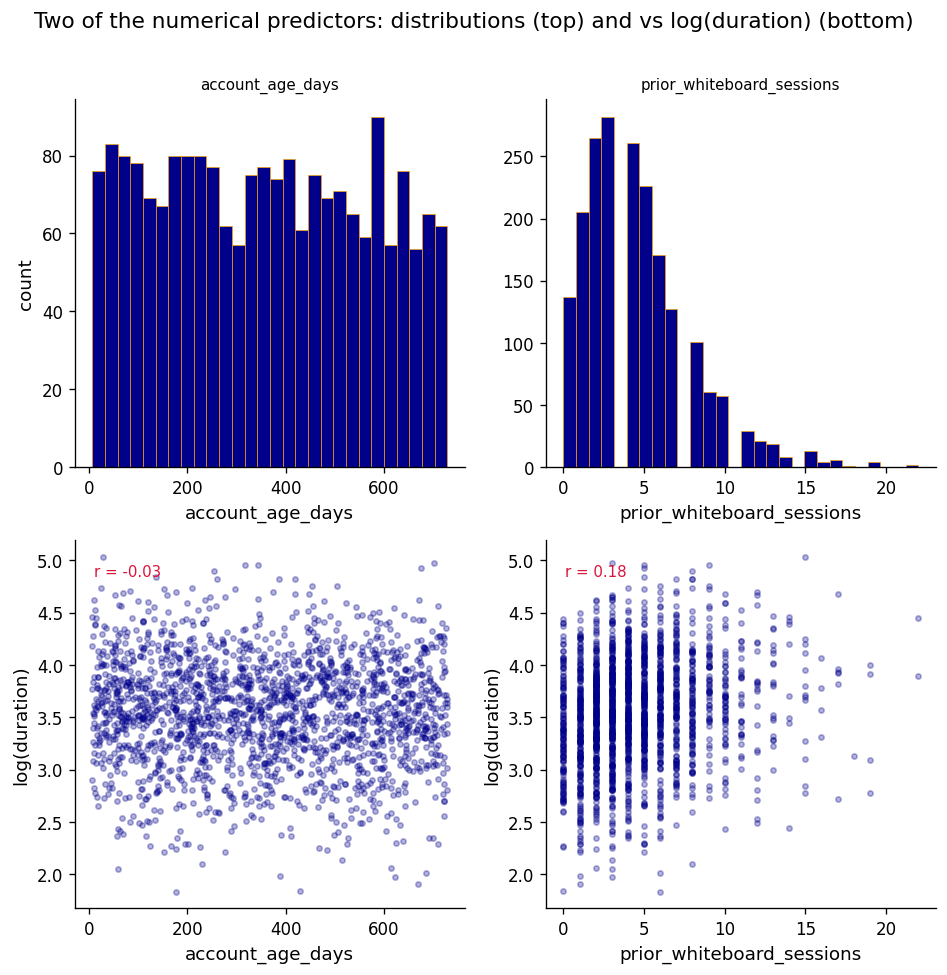

In [15]:
num_predictors = [
    'account_age_days',
    'prior_whiteboard_sessions',
]

n = len(num_predictors)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle('Two of the numerical predictors: distributions (top) and vs log(duration) (bottom)',
             fontsize=13, y=1.01)

for j, col in enumerate(num_predictors):

    # top row: histogram
    axes[0, j].hist(df_ab[col], bins=28, color='darkblue', edgecolor='orange', lw=0.4)
    axes[0, j].set_title(col, fontsize=9)
    axes[0, j].set_xlabel(col)
    axes[0, j].set_ylabel('count' if j == 0 else '')

    # bottom row: scatterplot
    r = df_ab[col].corr(log_dur)
    axes[1, j].scatter(df_ab[col], log_dur, color='darkblue', alpha=0.3, s=10)
    axes[1, j].set_xlabel(col)
    axes[1, j].set_ylabel('log(duration)')
    axes[1, j].annotate(f'r = {r:.2f}', xy=(0.05, 0.9),
                        xycoords='axes fraction', fontsize=9, color='crimson')

plt.tight_layout()
plt.show()

**✏️ Your interpretation (A1.3):**

The distribution of account_age_days is almost uniform with little skewness, and it has almost no correlation with log(duration) (r = -0.03). On the other hand, prior_whiteboard_sessions is right-skewed with a long tail, so it is a good candidate for log transformation. It also has a weak positive correlation with log(duration) (r = 0.18), making it a more promising predictor than account_age_days. Therefore, I would apply a log transformation to prior_whiteboard_sessions.
So, the two variables ai_suggestions_used and whiteboard_actions_per_session are excluded because they are outcomes of the treatment, not predictors of session duration.


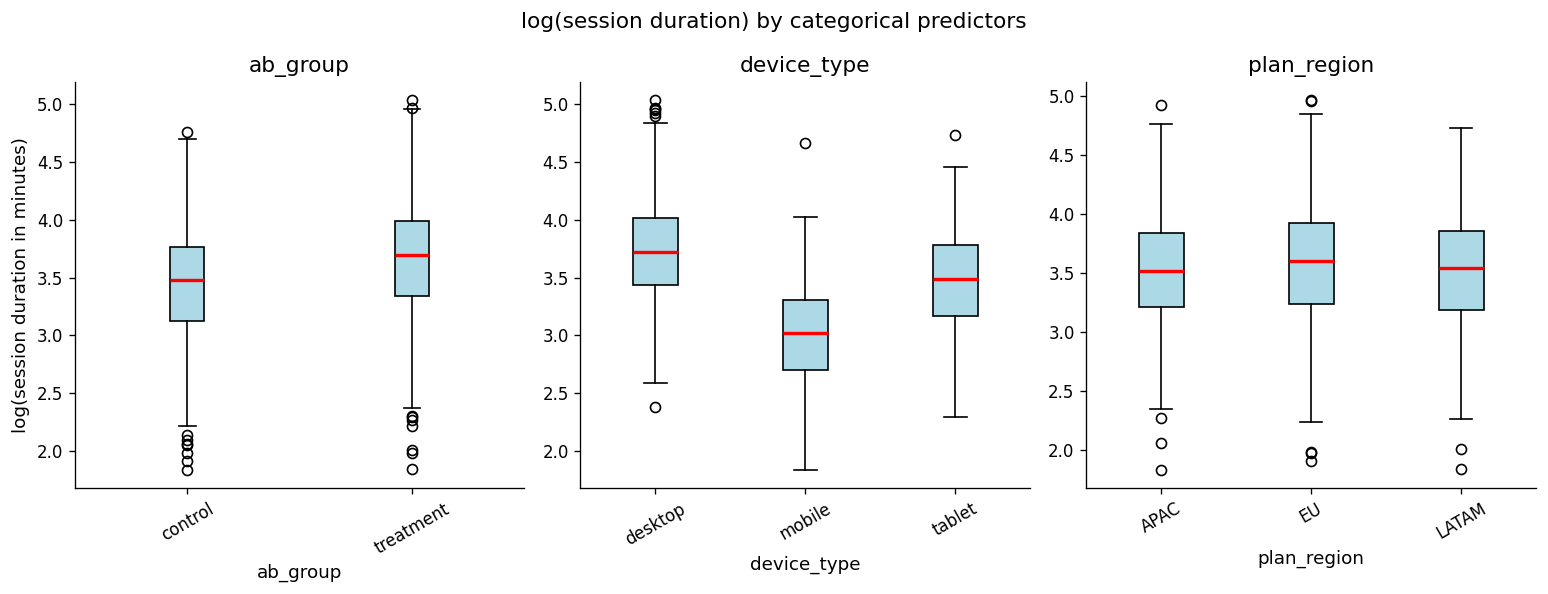

In [16]:
import numpy as np
import matplotlib.pyplot as plt

cat_predictors = ['ab_group', 'device_type', 'plan_region']

log_dur = np.log(df_ab['avg_whiteboard_session_duration_min'])

fig, axes = plt.subplots(1, len(cat_predictors), figsize=(13, 5))
fig.suptitle('log(session duration) by categorical predictors', fontsize=13)

for j, col in enumerate(cat_predictors):
    levels = sorted(df_ab[col].dropna().unique(), key=str)
    grouped = [log_dur[df_ab[col] == level] for level in levels]
    
    axes[j].boxplot(grouped, tick_labels=levels, patch_artist=True,
                    boxprops=dict(facecolor="lightblue"),
                    medianprops=dict(color='red', lw=2))
    axes[j].set_title(col)
    axes[j].set_xlabel(col)
    axes[j].set_ylabel('log(session duration in minutes)' if j == 0 else '')
    axes[j].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [ ]:
BEGIN
    Load baseline dataset

    // 1. Encode Categorical Variables
    Convert experimental group ('ab_group') into a binary integer indicator
    Generate dummy indicators (one-hot encoding) for device types, omitting the first category
    Generate dummy indicators (one-hot encoding) for regions, omitting the first category

    // 2. Perform Optional Transformations
    Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values

    // 3. Assemble Modeling Dataset
    Merge numerical characteristics, binary groups, and dummy indicators into matrix X
    Set target vector y as the log-transformed outcome variable

    // 4. Quality Control
    Verify that there are no missing (null) values in feature matrix X
    Inspect matrix dimensions and print a preview of the processed data
END

In [17]:
# Encode Categorical Variables
df_ab['ab_group_enc'] = (df_ab['ab_group'] == 'treatment').astype(int)
device_dummies = pd.get_dummies(df_ab['device_type'], prefix='device', drop_first=True).astype(int)
region_dummies = pd.get_dummies(df_ab['plan_region'], prefix='region', drop_first=True).astype(int)

# Perform Optional Transformations
log_account_age = np.log1p(df_ab['account_age_days'])
log_prior_whiteboard_sessions = np.log1p(df_ab['prior_whiteboard_sessions'])
log_num_collaborators = np.log1p(df_ab['num_collaborators'])

# Assemble Modeling Dataset
X = pd.concat([
    df_ab['ab_group_enc'].rename('ab_group'),
    log_account_age.rename('log_account_age_days'),
    log_prior_whiteboard_sessions.rename('log_whiteboard_sessions'),
    log_num_collaborators.rename('log_num_collaborators'),
    device_dummies,
    region_dummies
], axis=1)

#  Quality Control
y = np.log(df_ab['avg_whiteboard_session_duration_min'])

# result
assert X.isnull().sum().sum() == 0
print(f"Feature matrix shape: {X.shape}")
print(f"Missing values in X:  {X.isnull().sum().sum()}")
print(f"\nFeature columns:\n{X.columns.tolist()}")
X.head(3)

Feature matrix shape: (2000, 8)
Missing values in X:  0

Feature columns:
['ab_group', 'log_account_age_days', 'log_whiteboard_sessions', 'log_num_collaborators', 'device_mobile', 'device_tablet', 'region_EU', 'region_LATAM']


,ab_group,log_account_age_days,log_whiteboard_sessions,log_num_collaborators,device_mobile,device_tablet,region_EU,region_LATAM
0,0,6.171701,1.609438,1.386294,0,1,1,0
1,0,6.452049,2.302585,0.693147,0,0,0,0
2,0,5.075174,2.397895,1.791759,0,0,0,0


**✏️ Your interpretation (A2):**

-  ab_group: The treatment variable, included to measure the effect of having access to the AI assistant.
-  log_account_age_days: Included to measure how experienced a user is based on the age of their account. A log transformation is applied to reduce the influence of very large values.
-  log_prior_whiteboard_sessions: Included to measure how frequently the user used the whiteboard before the experiment, which indicates whether they were already a heavy user. A log transformation is applied because the variable is right-skewed.
-  log_num_collaborators: Included to measure whether users work mostly alone or in teams. A log transformation is applied because the variable is right-skewed.
-  device_mobile, device_tablet: Dummy variables created from one-hot encoding of device_type (desktop is the reference category). They are included because screen size and device type may affect session duration.
-  region_EU, region_LATAM: Dummy variables created from one-hot encoding of plan_region (NA is the reference category). They are included to control for regional differences in usage patterns.


### A3 — OLS Regression


In [18]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())


                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.354
Model:                                             OLS   Adj. R-squared:                  0.351
Method:                                  Least Squares   F-statistic:                     136.2
Date:                                 Sun, 05 Jul 2026   Prob (F-statistic):          1.31e-182
Time:                                         22:13:24   Log-Likelihood:                -1034.8
No. Observations:                                 2000   AIC:                             2088.
Df Residuals:                                     1991   BIC:                             2138.
Df Model:                                            8                                         
Covariance Type:                             nonrobust                                         
                              coef    st

#### A3.1 — Interpret the model

In [ ]:
BEGIN
    Input trained OLS regression model
    Input experimental dataframe

    // 1. Evaluate Model Fit
    Display model's R-squared value to assess variance explained

    // 2. Analyze Treatment Effect
    Extract coefficient and significance (p-value) for the A/B testing variable
    Convert the log-space treatment coefficient back to its scale in physical time (minutes) 
    Display treatment effect size and statistical significance

    // 3. Extract Significant Predictors
    Filter all model coefficients where p-value < 0.05
    FOR each significant variable:
        Display variable name, its directional coefficient, and its p-value
    END FOR
END

In [19]:
print(f"R²        = {model_ols.rsquared:.4f}")
print(f"Adj. R²   = {model_ols.rsquared_adj:.4f}")
print()

ab_coef = model_ols.params['ab_group']
ab_pval = model_ols.pvalues['ab_group']

# y = log(duration)
ab_pct_change = (np.exp(ab_coef) - 1)

control_mean = df_ab.loc[df_ab['ab_group'] == 'control', 'avg_whiteboard_session_duration_min'].mean()

ab_mins_effect = control_mean * (np.exp(ab_coef) - 1)

print(f"ab_group coefficient : {ab_coef:.4f}")
print(f"p-value              : {ab_pval:.4f}")
print(f"Back-transformed     : {ab_pct_change:.1f}% relative to control mean")
print(f"                     : ~= {ab_mins_effect:.1f} min above control mean ({control_mean:.1f} min)")

# significant predictors with p < 0.05
sig = model_ols.pvalues[model_ols.pvalues < 0.05].sort_values()
print('significant predictors are: ')
for var, pv in sig.items():
    coef = model_ols.params[var]
    print(f".  {var:<35s}.    coef = {coef:.4f}.    p={pv:.4f}")

R²        = 0.3538
Adj. R²   = 0.3512

ab_group coefficient : 0.2184
p-value              : 0.0000
Back-transformed     : 0.2% relative to control mean
                     : ~= 8.6 min above control mean (35.2 min)
significant predictors are: 
.  const                              .    coef = 3.4148.    p=0.0000
.  device_mobile                      .    coef = -0.7244.    p=0.0000
.  ab_group                           .    coef = 0.2184.    p=0.0000
.  device_tablet                      .    coef = -0.2565.    p=0.0000
.  log_whiteboard_sessions            .    coef = 0.1414.    p=0.0000
.  log_num_collaborators              .    coef = 0.0878.    p=0.0000


**✏️ Results paragraph (A3):**

- The treatment effect estimate and its significance:Users who had access to the AI assistant spent 8.6 minutes longer in a session on average than users in the control group. The result is statistically significant because p < 0.001.
- R² and what it tells you about model fit:The model explains 35.4% of the variance in session duration. For human behavior data, this is a relatively high R², which means the model explains the data reasonably well.
- At least two other notable predictors and their direction:The coefficient for device_mobile is -0.7244, which means mobile users tend to have shorter session durations than desktop users. The coefficient for log_prior_whiteboard_sessions is 0.1414, which means users who used the whiteboard more often before the experiment tend to have longer session durations.
- Whether the AI assistant's effect is practically meaningful (not just statistically significant):An increase of 8.6 minutes is about 24% of the control group's average session duration (35.2 minutes). This is a meaningful difference for Phigma because users spend about one-quarter more time in a session, which could improve user engagement.


#### A3.2 — Regression diagnostics

In [ ]:
BEGIN
    Extract predictions and error terms (residuals) from regression model
    Initialize a side-by-side diagnostic visualization layout

    // Check for uniform variance (homoscedasticity)
    Draw scatter plot of prediction values vs residuals
    Overlay a horizontal zero-error baseline reference line
    
    // Check for normality of errors
    Draw a Q-Q plot of residuals against a normal theoretical distribution

    Render diagnostic plots
END

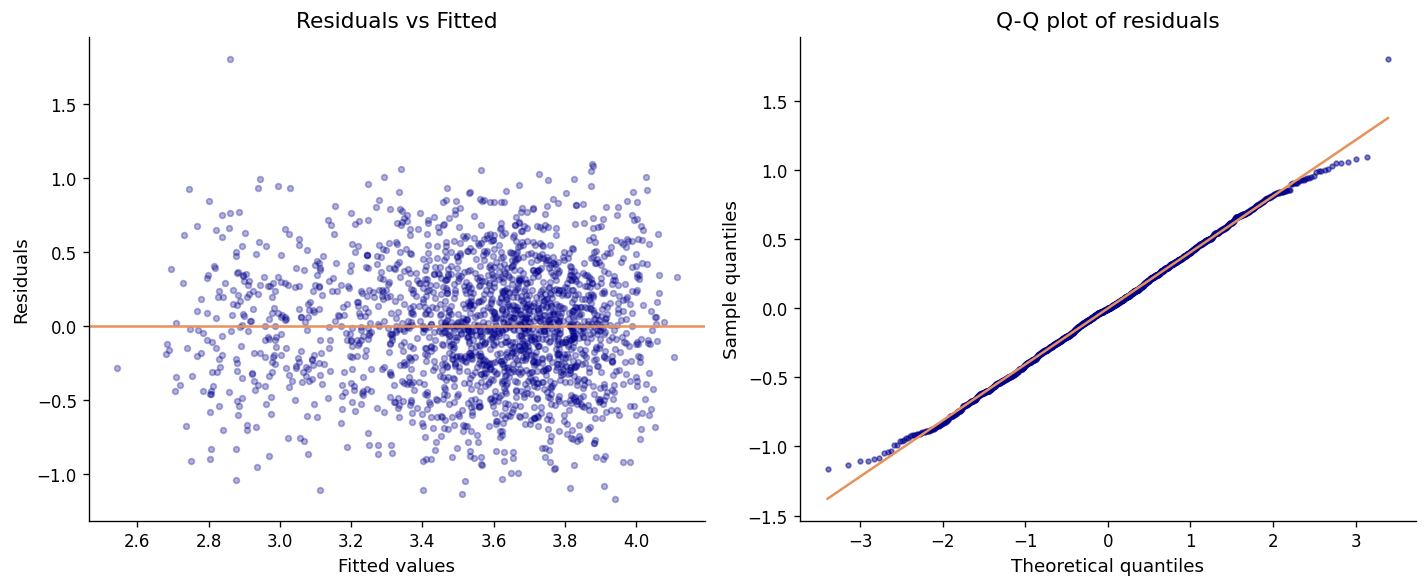

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_hat = model_ols.fittedvalues
resid  = model_ols.resid

#  Residuals vs Fitted
axes[0].scatter(y_hat, resid, color='darkblue', alpha=0.3, s=12)
axes[0].axhline(0, color=ACCENT, lw=1.5)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q plot of residuals
(osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
axes[1].scatter(osm, osr, color='darkblue', s=8, alpha=0.5)
axes[1].plot([osm.min(), osm.max()],
             [slope*osm.min()+intercept, slope*osm.max()+intercept],
             color=ACCENT, lw=1.5)
axes[1].set_title('Q-Q plot of residuals')
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')

plt.tight_layout()
plt.show()

**✏️ Your interpretation (A3.2):**

- Residuals vs Fitted: The residuals are randomly scattered around zero, which suggests that the linearity and constant variance assumptions are reasonably satisfied.
- Q-Q Plot: The points in the middle of the Q-Q plot are close to the diagonal line, which indicates that the residuals are approximately normally distributed.
- Patterns of concern: There is no clear pattern in the Residuals vs Fitted plot. However, there are fewer points on the right side (at higher fitted values), which may be a small concern. In the Q-Q plot, the points at both tails, especially the upper tail, deviate slightly from the diagonal line. This suggests some departures from normality in the tails, but the overall fit is still reasonable.


### A4 — Exploratory Interaction Analysis (bonus_added june23)

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

I am testing the interaction between ab_group and prior_whiteboard_sessions. My theoretical reasoning is that users with little prior experience (few prior_whiteboard_sessions) have not yet fully learned how to use the whiteboard tool, so the AI assistant feature can guide them by suggesting what to do next. it will be providing a larger benefit. Experienced users, on the other hand, already know how to use the tool effectively on their own, so the AI assistant is likely to add less additional value for them (a ceiling effect). Based on this reasoning, I predict that beginner users (low prior_whiteboard_sessions) will benefit more from the AI assistant, meaning I expect a negative interaction coefficient.  the positive effect of ab_group should shrink as prior_whiteboard_sessions increases.


In [21]:
# YOUR CODE HERE

# Step 1: Create the interaction term
#BEGIN[Claude][https://claude.ai]["Help me create the interaction term ab_group × prior_whiteboard_sessions and add it to the OLS model"]
df_ab['ab_x_whiteboard'] = df_ab['ab_group_enc'] * log_prior_whiteboard_sessions

# Step 2: Add the interaction term to your feature matrix and refit OLS
interaction_col = df_ab[['ab_x_whiteboard']]
#END[Claude]
X_interact = pd.concat([X_const, interaction_col], axis=1)
model_interact = sm.OLS(y, X_interact).fit()
print(model_interact.summary())

                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.355
Model:                                             OLS   Adj. R-squared:                  0.352
Method:                                  Least Squares   F-statistic:                     121.6
Date:                                 Sun, 05 Jul 2026   Prob (F-statistic):          3.38e-182
Time:                                         22:13:38   Log-Likelihood:                -1033.3
No. Observations:                                 2000   AIC:                             2087.
Df Residuals:                                     1990   BIC:                             2143.
Df Model:                                            9                                         
Covariance Type:                             nonrobust                                         
                              coef    st

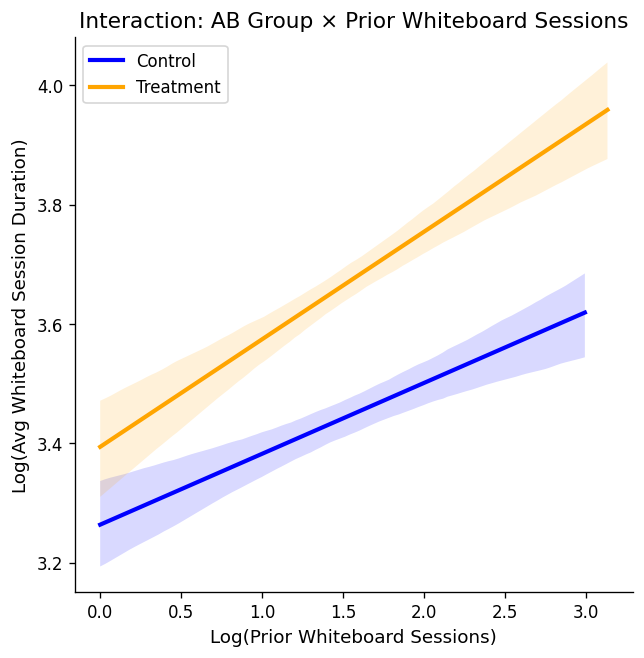

In [24]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines
df_ab['log_whiteboard_sessions'] = log_prior_whiteboard_sessions
df_ab['log_duration'] = y

#BEGIN[Claude][https://claude.ai]["Create code for the A4 visualization task that overlays regression lines for each AB group to compare the difference in slopes representing the interaction effect"]
plt.figure(figsize=(6, 6))
sns.regplot(
    data=df_ab[df_ab['ab_group_enc'] == 0],
    x='log_whiteboard_sessions', y='log_duration',
    label='Control', scatter=False, line_kws={'color': 'blue', 'linewidth': 2.5}
)
sns.regplot(
    data=df_ab[df_ab['ab_group_enc'] == 1],
    x='log_whiteboard_sessions', y='log_duration',
    label='Treatment', scatter=False, line_kws={'color': 'orange', 'linewidth': 2.5}
)
#END[Claude]
plt.xlabel('Log(Prior Whiteboard Sessions)')
plt.ylabel('Log(Avg Whiteboard Session Duration)')
plt.title('Interaction: AB Group × Prior Whiteboard Sessions')
plt.legend()
plt.show()


**✏️ Your interpretation (A4):**

My hypothesis was not supported.I predicted a negative interaction coefficient, but the actual coefficient (0.0487) was positive, suggesting more experienced users may benefit slightly more from the AI assistant, not less. The regression plot supports this, with the gap between Treatment and Control widening as prior_whiteboard_sessions increases. However, the coefficient is not statistically significant (p = 0.079), so this should be treated as a tendency rather than a confirmed effect. Phigma should avoid targeting the rollout narrowly based on this result and instead collect more data to confirm the pattern before making a decision.


---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [26]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


Shape: (3000, 15)

Column types:
user_id                         object
signup_date                     object
first_session_date              object
device_type                     object
country_tier                    object
referral_source                 object
num_sessions_30d                 int64
total_time_min_30d               int64
projects_created_30d             int64
exports_30d                      int64
collaborators_invited_30d        int64
support_tickets_30d              int64
used_premium_feature_preview     int64
ai_assistant_sessions_30d        int64
subscribed                       int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [27]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [66]:
# YOUR CODE HERE
# 1. Parse dates
df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
df_sub['days_to_first_session'] = (
    df_sub['first_session_date'] - df_sub['signup_date']
).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
df_sub['avg_session_duration_min'] = np.where(
    df_sub['num_sessions_30d'] == 0,
    0,
    df_sub['total_time_min_30d'] / df_sub['num_sessions_30d']
)

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
device_dummies = pd.get_dummies(df_sub['device_type'], prefix="device", drop_first=True)

# 6. One-hot encode referral_source (drop first level)
referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True)

# 7. Encode country_tier — ordinal (justified below)
df_sub['country_tier_enc'] = df_sub['country_tier'].map(
    {'tier_1': 1, 'tier_2': 2, 'tier_3': 3}
)

# 8. Assemble final feature matrix
raw_numeric = [
    'num_sessions_30d', 'total_time_min_30d', 'projects_created_30d',
    'exports_30d', 'collaborators_invited_30d', 'support_tickets_30d',
    'used_premium_feature_preview', 'ai_assistant_sessions_30d'
]

engineered = [
    'days_to_first_session', 'avg_session_duration_min', 'is_weekend_signup',
    'country_tier_enc'
]
X_sub = pd.concat(
    [df_sub[raw_numeric + engineered], device_dummies, referral_dummies],
    axis=1
)

y_sub = df_sub['subscribed']

# Confirm
print(f"Any NaN values : {X_sub.isnull().any().any()}")
print(f"All numeric    : {all(X_sub.dtypes != object)}")
print(f"Feature matrix shape: {X_sub.shape}")
print(f"\nFeature names:\n{list(X_sub.columns)}")
X_sub.head(3)

Any NaN values : False
All numeric    : True
Feature matrix shape: (3000, 17)

Feature names:
['num_sessions_30d', 'total_time_min_30d', 'projects_created_30d', 'exports_30d', 'collaborators_invited_30d', 'support_tickets_30d', 'used_premium_feature_preview', 'ai_assistant_sessions_30d', 'days_to_first_session', 'avg_session_duration_min', 'is_weekend_signup', 'country_tier_enc', 'device_mobile', 'device_tablet', 'ref_paid_ad', 'ref_referral', 'ref_social']


,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,days_to_first_session,avg_session_duration_min,is_weekend_signup,country_tier_enc,device_mobile,device_tablet,ref_paid_ad,ref_referral,ref_social
0,1,96,1,0,0,0,1,6,5,96.0000,0,1,False,True,False,False,False
1,15,267,8,1,5,0,0,0,0,17.8000,0,2,False,True,False,False,True
2,16,263,0,0,3,3,1,4,14,16.4375,0,1,False,False,False,False,False


**✏️ Your interpretation (B1):**

- days_to_first_session: if a user starts using the product soon after signing up, they might be more engaged, so they could be more likely to subscribe.
- avg_session_duration_min: if a user spends more time per session, it might mean they find the tool useful, so they could be more likely to subscribe.
- is_weekend_signup: users who sign up on weekends might be doing it for personal reasons, not for work, so their engagement could be different.
- country_tier_enc: users from different country tiers might have different price sensitivity, which could affect whether they subscribe.

For avg_session_duration_min, I used np.where to fix the divide-by-zero problem. If num_sessions_30d is 0, I set avg_session_duration_min to 0. Otherwise, division by zero would cause an error.


### B2 — EDA for Subscription


In [29]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


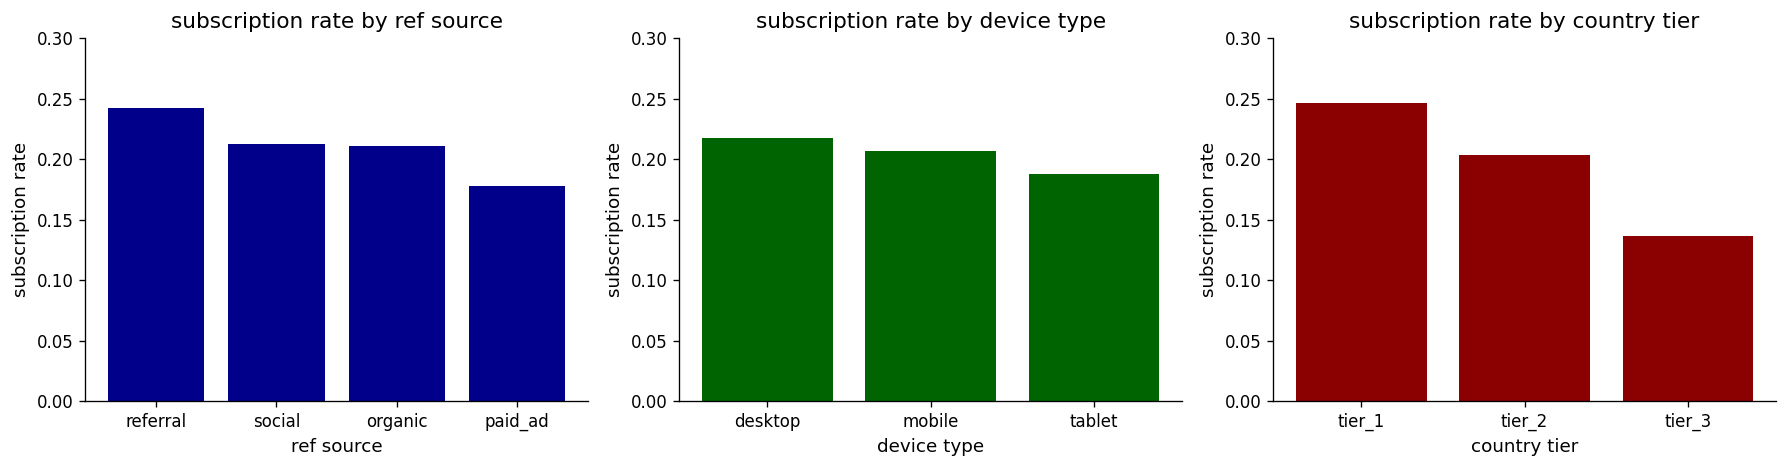

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sub_by_ref = df_sub.groupby('referral_source')['subscribed'].mean().sort_values(ascending=False)
axes[0].bar(sub_by_ref.index, sub_by_ref.values, color="darkblue")
axes[0].set_title("subscription rate by ref source")
axes[0].set_xlabel("ref source")
axes[0].set_ylabel("subscription rate")
axes[0].set_ylim(0, 0.3)


sub_by_device = df_sub.groupby('device_type')['subscribed'].mean().sort_values(ascending=False)
axes[1].bar(sub_by_device.index, sub_by_device.values, color="darkgreen")
axes[1].set_title("subscription rate by device type")
axes[1].set_xlabel("device type")
axes[1].set_ylabel("subscription rate")
axes[1].set_ylim(0, 0.3)

sub_by_tier = df_sub.groupby('country_tier')['subscribed'].mean().sort_values(ascending=False)
axes[2].bar(sub_by_tier.index, sub_by_tier.values, color="darkred")
axes[2].set_title("subscription rate by country tier")
axes[2].set_xlabel("country tier")
axes[2].set_ylabel("subscription rate")
axes[2].set_ylim(0, 0.3)

plt.tight_layout()
plt.show()

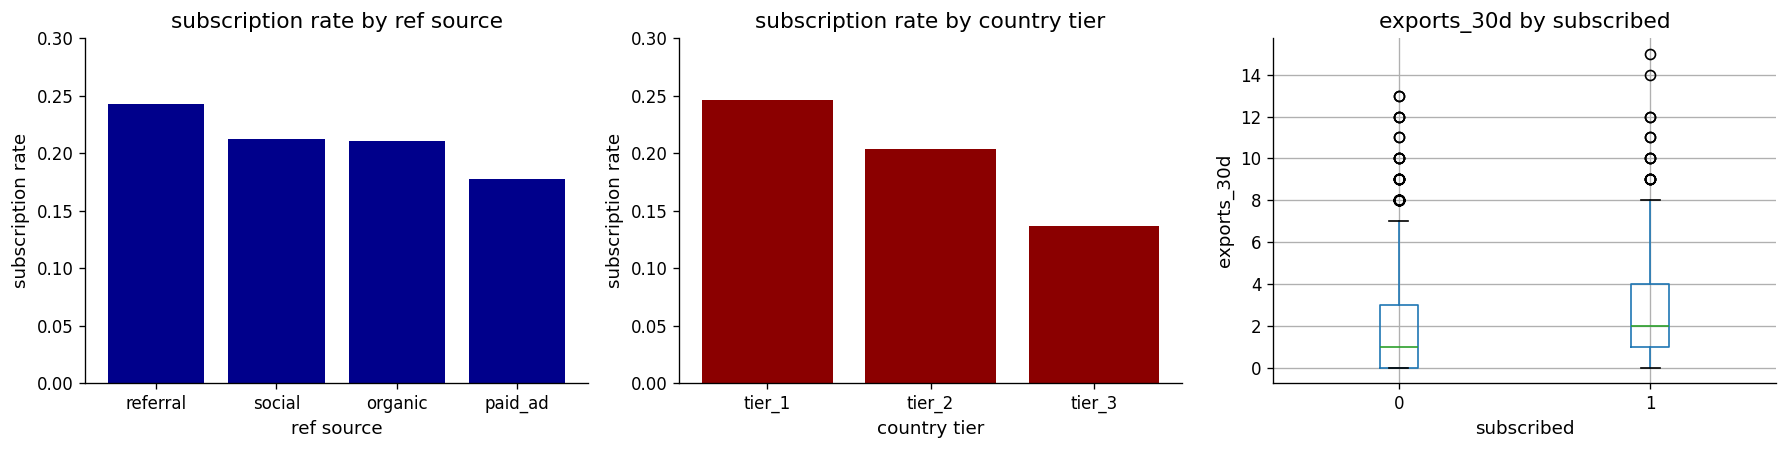

In [32]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot1: subscription rate by referral_source
sub_by_ref = df_sub.groupby('referral_source')['subscribed'].mean().sort_values(ascending=False)
axes[0].bar(sub_by_ref.index, sub_by_ref.values, color="darkblue")
axes[0].set_title("subscription rate by ref source")
axes[0].set_xlabel("ref source")
axes[0].set_ylabel("subscription rate")
axes[0].set_ylim(0, 0.3)

# Plot2:subscription rate by country_tier
sub_by_tier = df_sub.groupby('country_tier')['subscribed'].mean().sort_values(ascending=False)
axes[1].bar(sub_by_tier.index, sub_by_tier.values, color="darkred")
axes[1].set_title("subscription rate by country tier")
axes[1].set_xlabel("country tier")
axes[1].set_ylabel("subscription rate")
axes[1].set_ylim(0, 0.3)


# Plot3:exports_30d distribution by subscribed (0 vs 1)
df_sub.boxplot(column='exports_30d', by='subscribed', ax=axes[2])
axes[2].set_title("exports_30d by subscribed")
axes[2].set_xlabel("subscribed")
axes[2].set_ylabel("exports_30d")
plt.suptitle("")

plt.tight_layout()
plt.show()


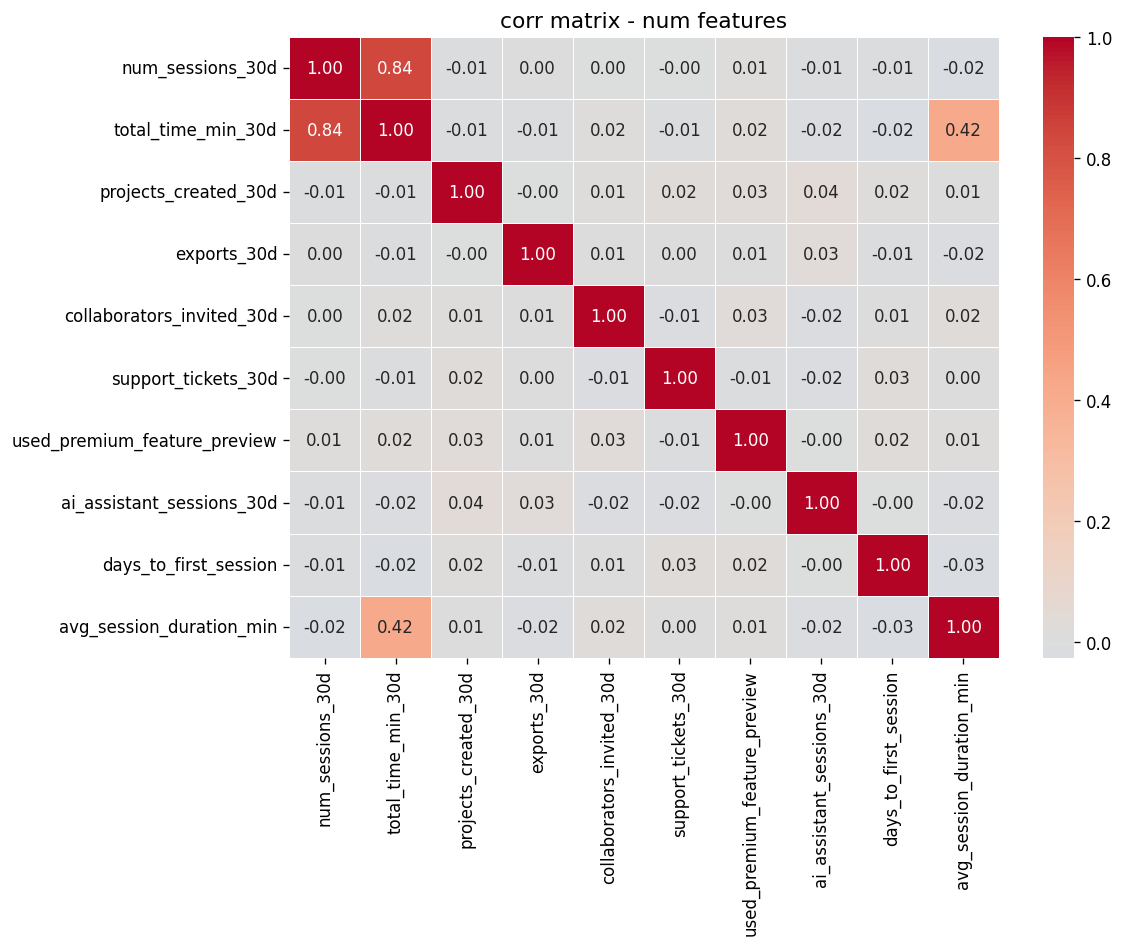

In [35]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
# numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
# corr = X_sub[numeric_features].corr()
# Plot as heatmap

numeric_features = [
    'num_sessions_30d', 'total_time_min_30d', 'projects_created_30d',
    'exports_30d', 'collaborators_invited_30d', 'support_tickets_30d',
    'used_premium_feature_preview', 'ai_assistant_sessions_30d',
    'days_to_first_session', 'avg_session_duration_min'
]

corr = X_sub[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.35
)

ax.set_title("corr matrix - num features")
plt.tight_layout()
plt.show()

**✏️ Your interpretation (B2):**

The features most strongly associated with subscription in the EDA are country_tier and referral_source, with subscription rates ranging from about 25% (tier_1) to 14% (tier_3), and referral traffic showing the highest rate among referral sources. One somewhat surprising finding is that ai_assistant_sessions_30d shows almost no correlation with any other numeric feature, suggesting AI assistant usage is fairly independent of overall engagement. I also noticed that num_sessions_30d and total_time_min_30d are highly correlated r = 0.84.This is a concern because using both features together in the logistic regression could make the model unstable and harder to interpret.


### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [67]:
# YOUR CODE HERE

X_const_sub = sm.add_constant(X_sub.astype(float))

model_logit = sm.Logit(y_sub, X_const_sub).fit()

print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.440520
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2982
Method:                           MLE   Df Model:                           17
Date:                Sun, 05 Jul 2026   Pseudo R-squ.:                  0.1392
Time:                        22:03:27   Log-Likelihood:                -1321.6
converged:                       True   LL-Null:                       -1535.2
Covariance Type:            nonrobust   LLR p-value:                 3.542e-80
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.5253      0.325     -7.772      0.000

In [39]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
# odds_ratios = np.exp(model_logit.params)
# conf_int    = np.exp(model_logit.conf_int())
# Combine into a readable table and display
# Filter to significant only: p < 0.05

# or stand for odds ratios
odds_ratios = np.exp(model_logit.params)

conf_int = np.exp(model_logit.conf_int())
conf_int.columns = ["OR_lower_95", "OR_upper_95"]

or_table = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    'OR lower 95%': conf_int['OR_lower_95'],
    'OR upper 95%': conf_int['OR_upper_95'],
    'p-value': model_logit.pvalues
})

significants = or_table[
    (or_table['p-value'] < 0.05) & (or_table.index != 'const')
].sort_values('Odds Ratio', ascending=False)

print(significants.round(4).to_string())


                              Odds Ratio  OR lower 95%  OR upper 95%  p-value
used_premium_feature_preview      4.3470        3.5745        5.2864   0.0000
exports_30d                       1.2142        1.1633        1.2674   0.0000
support_tickets_30d               1.1673        1.0727        1.2702   0.0003
collaborators_invited_30d         1.0632        1.0178        1.1106   0.0059
avg_session_duration_min          1.0315        1.0112        1.0523   0.0023
days_to_first_session             0.9114        0.8872        0.9364   0.0000
country_tier_enc                  0.7001        0.6158        0.7959   0.0000


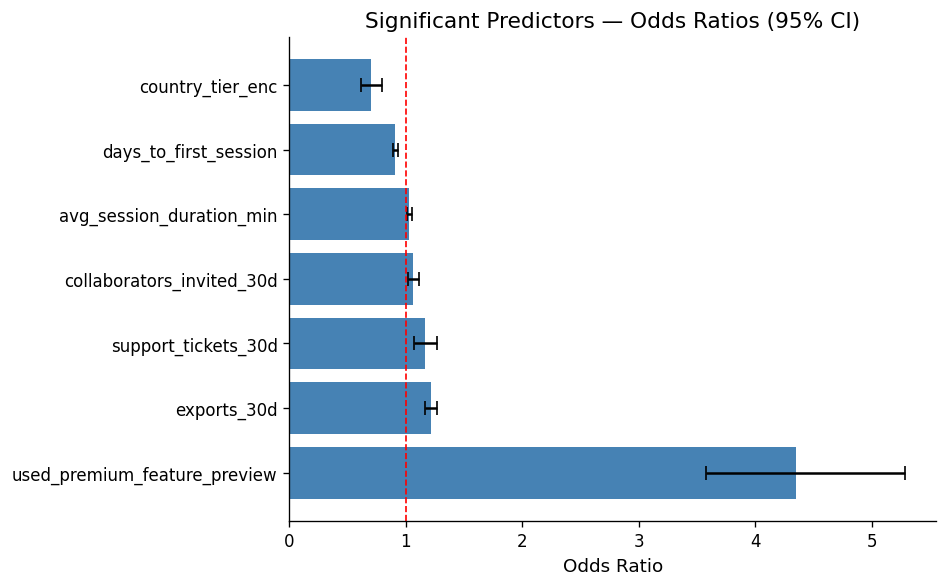

In [41]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude

fig, ax = plt.subplots(figsize=(8, 5))

y_pos = np.arange(len(significants))
#BEGIN[Claude][https://claude.ai]["Show confidence intervals"]
errors = [
    significants['Odds Ratio'] - significants['OR lower 95%'],
    significants['OR upper 95%'] - significants['Odds Ratio']
]

ax.barh(y_pos, significants['Odds Ratio'], color="steelblue")
ax.errorbar(significants['Odds Ratio'], y_pos, xerr=errors, fmt='none', ecolor='black', capsize=4)
#END
ax.axvline(x=1, color='red', linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(significants.index)
ax.set_xlabel("Odds Ratio")
ax.set_title("Significant Predictors — Odds Ratios (95% CI)")

plt.tight_layout()
plt.show()

**✏️ Results paragraph (B3):**

Users who previewed a premium feature were about 4.3 times more likely to subscribe than users who did not. Each additional export in the past 30 days was linked to about 1.2 times higher odds of subscribing. The further a user's country tier was from tier_1, the lower their odds of subscribing, with an odds ratio of about 0.7. The size of the used_premium_feature_preview effect was interesting. It was much larger than every other predictor, and its confidence interval was also quite wide whihc is about 3.6 to 5.3. This might be because users who try the premium feature are likely already interested in paid features, so this variable may be capturing users who already intended to subscribe, rather than a small nudge like the AI assistant.


### B4 — Logistic Regression with sklearn (Predictive)


In [45]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
# X_train, X_test, y_train, y_test = train_test_split(
#     X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
# )
# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
# print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")

X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")

Train: (2400, 17)  |  Test: (600, 17)
Train positive rate: 0.208  |  Test positive rate: 0.208


In [46]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
# clf_lr = LogisticRegression(max_iter=1000, random_state=42)
# clf_lr.fit(X_train, y_train)
# y_pred_lr = clf_lr.predict(X_test)
# y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train_scaled, y_train)

y_pred_lr = clf_lr.predict(X_test_scaled)
y_prob_lr = clf_lr.predict_proba(X_test_scaled)[:, 1]

print(f"{X_train_scaled.shape[0]}")
print(f"{X_test_scaled.shape[0]}")


2400
600


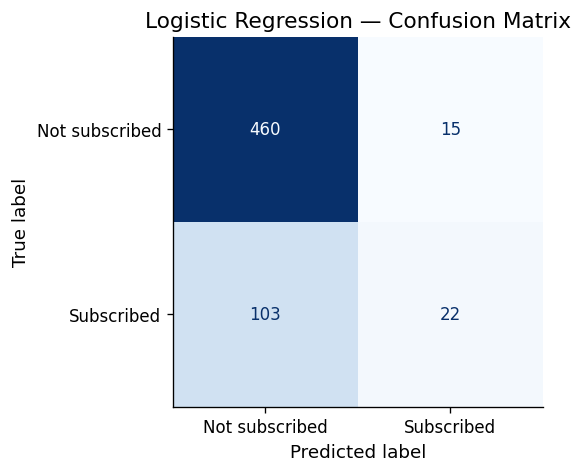

In [48]:
# YOUR CODE HERE
# Confusion matrix heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()



In [49]:
# YOUR CODE HERE
# Classification report
print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


                precision    recall  f1-score   support

Not subscribed       0.82      0.97      0.89       475
    Subscribed       0.59      0.18      0.27       125

      accuracy                           0.80       600
     macro avg       0.71      0.57      0.58       600
  weighted avg       0.77      0.80      0.76       600

ROC-AUC: 0.7373


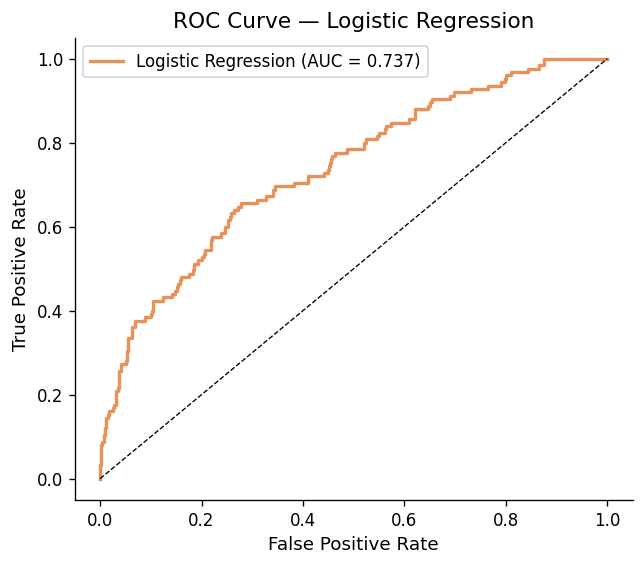

In [52]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.show()



**✏️ Your interpretation (B4):**

I think recall is the most important metric here, because recall represents the proportion of users who actually subscribed that the model correctly identified. The higher the recall, the fewer subscribers the model misses.
The model produces 103 false negatives. This means that out of 125 users who actually subscribed, the model incorrectly predicted 103 of them as "not subscribed."
From Phigma's business perspective, the cost of a false negative is that Phigma never reaches out to a user who was actually likely to subscribe. As a result, Phigma misses a potential customer, which represents a lost business opportunity.


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `[Random Forest]`

**Conceptual explanation (write this before any code):**

I chose Random Forest. It works by building many decision trees. Each tree is trained on a random part of the data and a random subset of features, and the final prediction comes from combining the votes of all the trees. To optimize, each tree tries to split the data into groups that are as pure as possible with respect to the outcome (subscribed or not). The structural difference from logistic regression is that logistic regression assumes a linear relationship, while Random Forest can find non-linear relationships and interactions between features. This dataset has features like num_sessions_30d and total_time_min_30d that are highly correlated with each other, and Random Forest can handle correlated features better than logistic regression, so it might perform differently.


### C2 — Fit and Evaluate


In [53]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
from sklearn.ensemble import RandomForestClassifier

# Fit with default hyperparameters
clf_c = RandomForestClassifier(random_state=42)   # add random_state if supported
clf_c.fit(X_train, y_train)
y_pred_c = clf_c.predict(X_test)
y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)


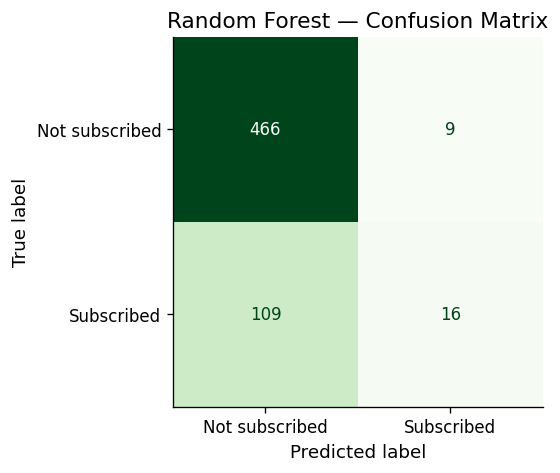

In [54]:
# YOUR CODE HERE
# Confusion matrix
cm_c = confusion_matrix(y_test, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_c, display_labels=['Not subscribed', 'Subscribed'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
plt.title('Random Forest — Confusion Matrix')
plt.show()

In [55]:
# YOUR CODE HERE
# Classification report + ROC-AUC
print(classification_report(y_test, y_pred_c, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_c):.4f}")


                precision    recall  f1-score   support

Not subscribed       0.81      0.98      0.89       475
    Subscribed       0.64      0.13      0.21       125

      accuracy                           0.80       600
     macro avg       0.73      0.55      0.55       600
  weighted avg       0.77      0.80      0.75       600

ROC-AUC: 0.6476


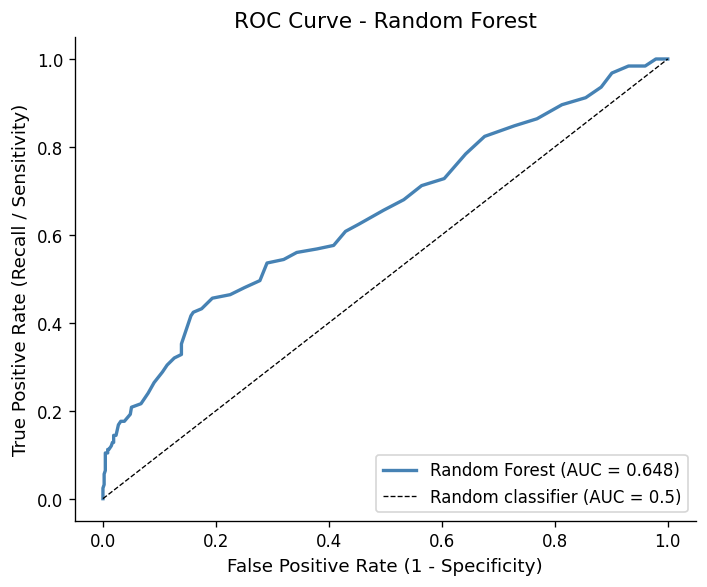

In [56]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_c)
auc_c = roc_auc_score(y_test, y_prob_c)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    fpr_c, tpr_c,
    color='steelblue', lw=2,
    label=f'Random Forest (AUC = {auc_c:.3f})'
)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax.set_title('ROC Curve - Random Forest')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### C3 — Model Comparison


In [58]:
# YOUR CODE HERE
# Summary comparison table
metrics = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [auc_lr, auc_c],
    'F1 (class 1)': [0.27, 0.21],
    'Precision (class 1)': [0.59, 0.64],
    'Recall (class 1)': [0.18, 0.13],
}
pd.DataFrame(metrics).set_index('Model').round(4)


,ROC-AUC,F1 (class 1),Precision (class 1),Recall (class 1)
Model,,,,
Logistic Regression,0.7373,0.27,0.59,0.18
Random Forest,0.6476,0.21,0.64,0.13


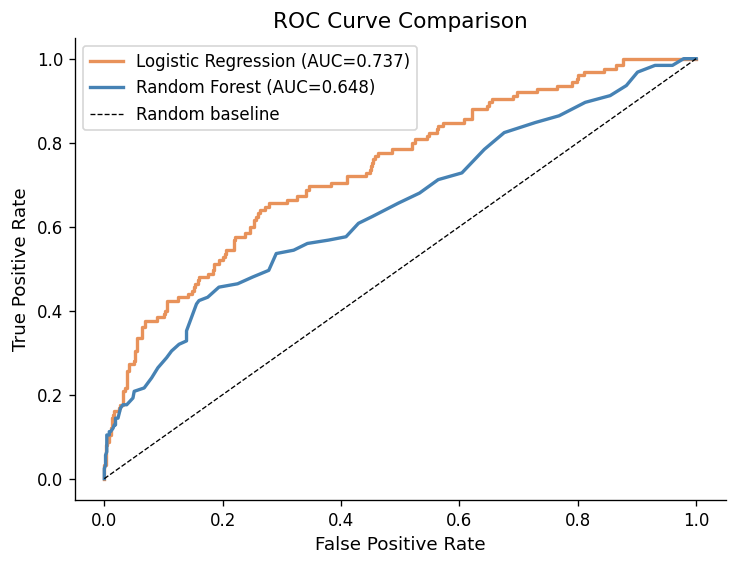

In [60]:
# YOUR CODE HERE
# Dual ROC curve plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'Random Forest (AUC={auc_c:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()


**✏️ Comparison paragraph (C3):**

Logistic regression performed better overall. Its ROC-AUC was 0.737, higher than Random Forest's 0.648, a difference of about 0.09. One reason for this is that, based on the B2 correlation heatmap, the relationships between variables in this dataset were mostly simple and linear. Logistic regression can only draw a straight decision boundary, while Random Forest can create much more complex boundaries. But since this data didn't have strong non-linear patterns, Random Forest's extra flexibility may have backfired, causing it to learn noise instead of the real pattern (overfitting). Another possible reason is that the training data only had 2400 rows and 17 features, which might not have been enough for Random Forest to take full advantage of its complexity. In conclusion, my model performed worse not because I chose the wrong model, but because the properties of this dataset (simple structure, limited sample size, and class imbalance) didn't match well with Random Forest's complexity. I think this is a valid finding.


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [65]:
# YOUR CODE HERE (BONUS)
from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
#BEGIN[Claude][URL]["suggest candidate hyperparameters to tune for Random Forest using GridSearchCV (n_estimators, max_depth, min_samples_leaf, class_weight)"]
param_grid = {  'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': [None, 'balanced']}
#END[Claude]

# Run cross-validated search on the TRAINING SET ONLY
search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
search.fit(X_train, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
y_pred_tuned = search.best_estimator_.predict(X_test)
y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"Default test AUC:{auc_c:.4f}")
print("Did tuning meaningfully improve results? [Yes, the AUC improved from 0.65 to 0.72]")


Best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV AUC:     0.7333
Tuned test AUC:  0.7195
Default test AUC:0.6476
Did tuning meaningfully improve results? [Yes, the AUC improved from 0.65 to 0.72]


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
